# What Drives a Used Car's Price? — analysis

A short, honest modelling walk-through. Goal: predict a used car's resale price from what a buyer actually sees, state the error plainly, and don't cheat.

The cleaning/feature code lives in `train.py` and is reused here so this notebook and the shipped model can never disagree.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import train as T
plt.rcParams['figure.figsize'] = (7, 4)
df = T.load_clean()
print(df.shape)
df[['name','year','selling_price','km_driven','fuel','max_power_bhp','brand']].head()

(7903, 19)


,name,year,selling_price,km_driven,fuel,max_power_bhp,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,74.00,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,103.52,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,78.00,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,90.00,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,88.20,Maruti


## The target is heavily right-skewed
A few expensive cars stretch the tail. We train on `log(price)` so the model isn't dominated by them, then invert for reporting.

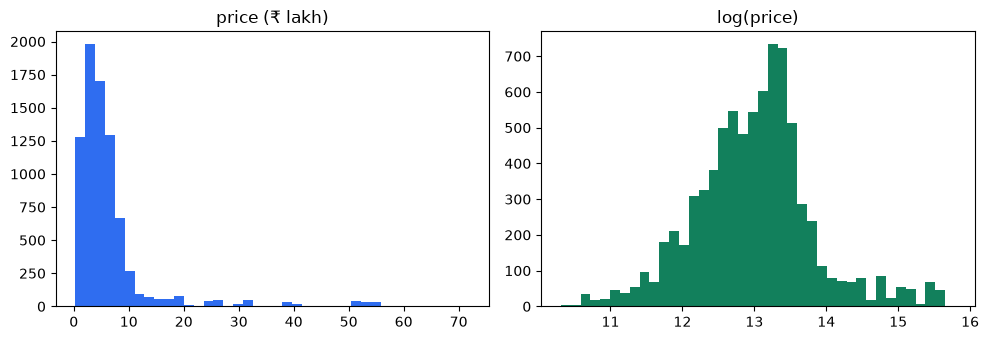

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(10,3.5))
ax[0].hist(df['selling_price']/1e5, bins=40, color='#2f6df0'); ax[0].set_title('price (₹ lakh)')
ax[1].hist(np.log1p(df['selling_price']), bins=40, color='#12805c'); ax[1].set_title('log(price)')
plt.tight_layout(); plt.show()

## Cars depreciate fast, then coast
Median resale price by age.

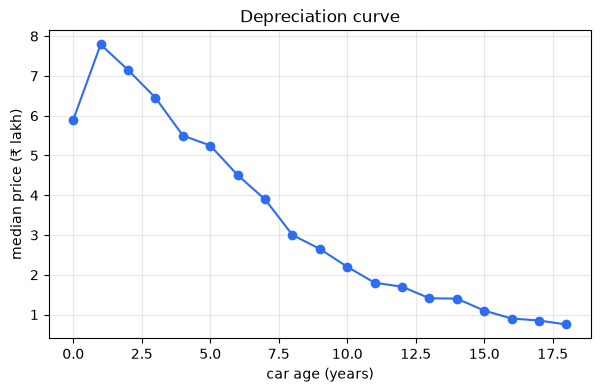

In [3]:
dep = df[df['car_age'].between(0,18)].groupby('car_age')['selling_price'].median()/1e5
dep.plot(marker='o', color='#2f6df0'); plt.ylabel('median price (₹ lakh)')
plt.xlabel('car age (years)'); plt.title('Depreciation curve'); plt.grid(alpha=.3); plt.show()

## Brand sets the baseline
Median price for the most common brands.

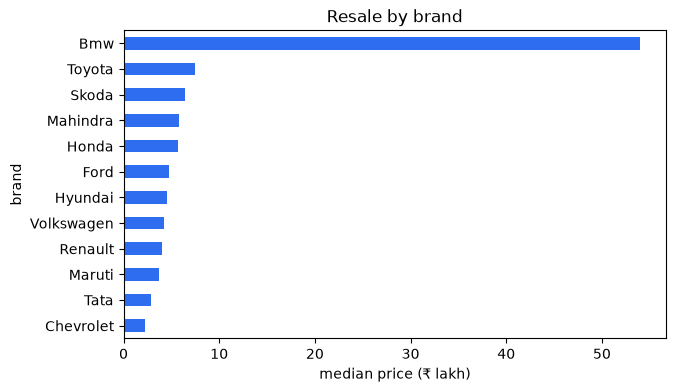

In [4]:
top = df['brand'].value_counts().head(12).index
(df[df['brand'].isin(top)].groupby('brand')['selling_price'].median()/1e5)\
  .sort_values().plot.barh(color='#2f6df0'); plt.xlabel('median price (₹ lakh)')
plt.title('Resale by brand'); plt.show()

## Modelling — honestly
One-hot the categoricals, hold out 20%, fit gradient boosting on `log(price)`. The only score that counts is on cars the model never saw, compared to a dumb median-guess baseline.

**The decision:** we do *not* feed in ex-showroom price (a near-answer proxy). The model earns its accuracy from age, km, brand, power, fuel, owners.

In [5]:
y = np.log1p(df['selling_price'].to_numpy(float))
X, names, _ = T.build_matrix(df, None)
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=0.2, random_state=42)
m = GradientBoostingRegressor(**T.GBR_KW).fit(Xtr, ytr)
pred, true = np.expm1(m.predict(Xte)), np.expm1(yte)
base = np.full_like(true, np.median(np.expm1(ytr)))
mae, bmae = mean_absolute_error(true,pred), mean_absolute_error(true,base)
print(f'model MAE    : ₹{mae:,.0f}')
print(f'baseline MAE : ₹{bmae:,.0f}')
print(f'improvement  : {100*(bmae-mae)/bmae:.1f}%')
print(f'R^2          : {r2_score(true,pred):.3f}')

model MAE    : ₹79,789
baseline MAE : ₹413,905
improvement  : 80.7%
R^2          : 0.974


## What the model leans on
Importances aggregated from one-hot columns back to the original field. Power, age and brand dominate — the same things a person weighs.

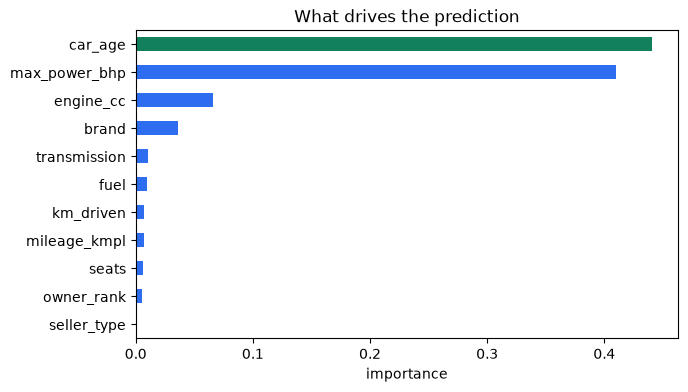

In [6]:
agg = {}
for n,v in zip(names, m.feature_importances_):
    agg[n.split('=')[0]] = agg.get(n.split('=')[0],0)+v
imp = pd.Series(agg).sort_values()
imp.plot.barh(color=['#12805c' if i==len(imp)-1 else '#2f6df0' for i in range(len(imp))])
plt.xlabel('importance'); plt.title('What drives the prediction'); plt.show()

## Limits (stated, not hidden)
Indian listings, ~2020 vintage. **Listing** prices, not final sale. Mileage mixes `kmpl`/`km per kg`. Rare brands bucketed as `Other`. This is a ballpark with a known ±₹80k typical error — the same model, exported to JSON, runs live in the browser demo.